In [81]:
# Importação das bibliotecas bases

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Algoritmo Adaline

1) **Batch Gradient Descent**: batch = True
2) **Stochastic Gradient Descent**: batch = False

In [82]:
class Adaline:
    def __init__(self, learning_rate=0.01, epochs=100, precision=0.001, batch=True, seed=None):
        self.weights = None
        self.errors_class = []
        self.errors_ms = []
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.seed = seed
        self.batch = batch
        self.precision = precision

    def activation_function(self, u):
        '''Função de ativação sinal'''
        return np.where(u >= 0, 1, -1)

    def fit(self, X: np.array, y: np.array):
        '''Algoritmo de Treinamento'''
        if self.seed is not None:
            np.random.seed(self.seed)

        n_features, k_samples = X.shape

        # Adiciona bias no vetor de entradas X
        X = np.vstack([np.ones((1, k_samples)), X]) # (n_features + 1, k_samples)

        # vetor de pesos gerados com valores pequenos aleatórios, incluindo o bias
        self.weights = np.random.randn(X.shape[0]) * 0.01 # (1, n_features + 1)

        for epoch in range(self.epochs):
            if self.batch:
                u = np.dot(self.weights.T, X) # dividiu-se pelo número de amostras para tornar o processo mais estável
                error = (y - u).flatten()
                self.weights += self.learning_rate * (X @ error.T) / k_samples
                loss = (error**2).mean()
            else:
                loss = 0
                for k in range(X.shape[1]):
                    x_k = X[:, k]
                    u_k = np.dot(self.weights.T, x_k)

                    error_k = y[0, k] - u_k
                    self.weights += self.learning_rate * error_k * x_k

                    loss += (error_k**2) / k_samples

                u = self.weights.T @ X

            y_class = self.activation_function(u)
            errors_count = np.sum(y_class != y)
            self.errors_class.append(errors_count / k_samples)

            self.errors_ms.append(loss)

            # Critério de parada
            if epoch > 0 and np.abs(self.errors_ms[-1] - self.errors_ms[-2]) <= self.precision:
                break

        return self.weights, epoch + 1, self.errors_class, self.errors_ms
        
    def predict(self, X:np.array):
        '''Algoritmo de Teste'''
        k_samples = X.shape[1]
        X = np.vstack([np.ones((1, k_samples)), X])
        u = self.weights.T @ X
        return self.activation_function(u)

    def accuracy(self, X:np.array, y:np.array):
        return np.mean(self.predict(X) == y)

#### Gráfico da Evolução dos Erros de Classificação e Erro Quadrático Médio

In [83]:
def plot_error(errors_class, title=None):
    plt.figure(figsize=(10, 6))
    plt.plot(errors_class, marker='o')
    plt.title(title)
    plt.xlabel('Épocas')
    plt.ylabel('Erro de classificação')
    plt.grid(True)
    plt.show()

def plot_error_qm(errors_class, title=None):
    plt.figure(figsize=(10, 6))
    plt.plot(errors_class, marker='o')
    plt.title(title)
    plt.xlabel('Épocas')
    plt.ylabel('Erro Quadrático Médio')
    plt.grid(True)
    plt.show()

### Gráfico da Fronteira de Decisão para dois atributos

In [84]:
def plot_decision_boundary(X, y, model, title=""):
    
    X = np.array(X)
    y = np.array(y).flatten()

    plt.figure(figsize=(10, 6))

    for label in np.unique(y):
        plt.scatter(
            X[0, y == label],
            X[1, y == label],
            label=f"Classe {label}"
        )

    w0, w1, w2 = model.weights # Pesos aprendidos pelo Perceptron com os dados de treinamento

    x1_vals = np.linspace(X[0, :].min(), X[0, :].max(), 100)

    if w2 != 0:
        x2_vals = -(w0 + w1 * x1_vals) / w2
        plt.plot(x1_vals, x2_vals, 'k--', label="Fronteira")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

### Dataset 1

* Realizar o treinamento e teste para taxa de aprendizado 0.01, precisão de 0.001 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais randomicamente.

In [85]:
df_train1 = pd.read_csv('train_dataset1.csv')
X_train1 = df_train1.drop('label', axis=1).values.T # (n_features, k_samples)
y_train1 = df_train1['label'].values.reshape(1, -1) # (, k_samples)

In [86]:
df_test1 = pd.read_csv('test_dataset1.csv')
X_test1 = df_test1.drop('label', axis=1).values.T
y_test1 = df_test1['label'].values.reshape(1, -1)

#### Batch Gradient Descent

##### Treinamento

In [87]:
modelBGD = Adaline(learning_rate=0.01, epochs=100, precision=0.001, batch=True, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelBGD.fit(X_train1, y_train1)


print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelBGD.accuracy(X_train1, y_train1))

Pesos: [-0.00969543 -0.31831328  0.38039237]
Épocas: 100
Acurácia: 0.9571428571428572


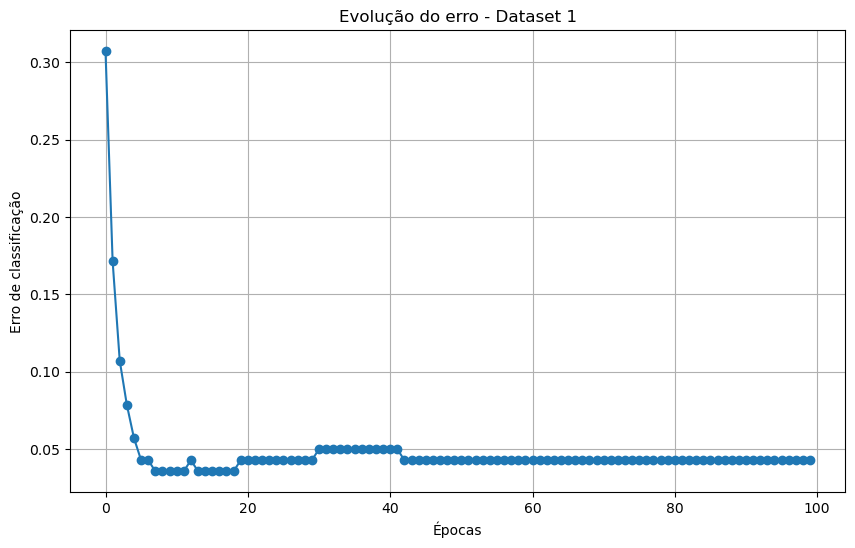

In [88]:
plot_error(modelBGD.errors_class, title="Evolução do erro - Dataset 1")

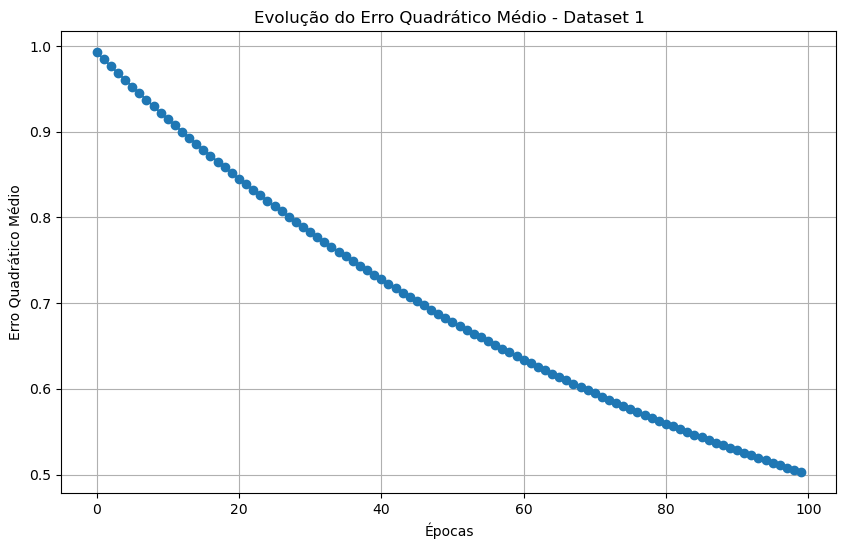

In [89]:
plot_error_qm(modelBGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 1")

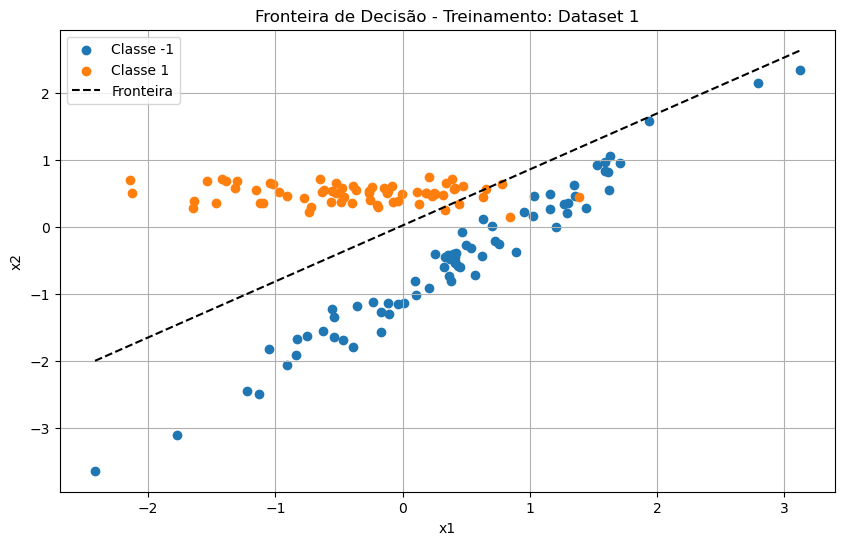

In [90]:
plot_decision_boundary(X_train1, y_train1, modelBGD, title='Fronteira de Decisão - Treinamento: Dataset 1')

##### Teste

In [91]:
print("Acurácia Treinamento:", modelBGD.accuracy(X_train1, y_train1))
print("Acurácia Teste:", modelBGD.accuracy(X_test1, y_test1))

Acurácia Treinamento: 0.9571428571428572
Acurácia Teste: 0.9333333333333333


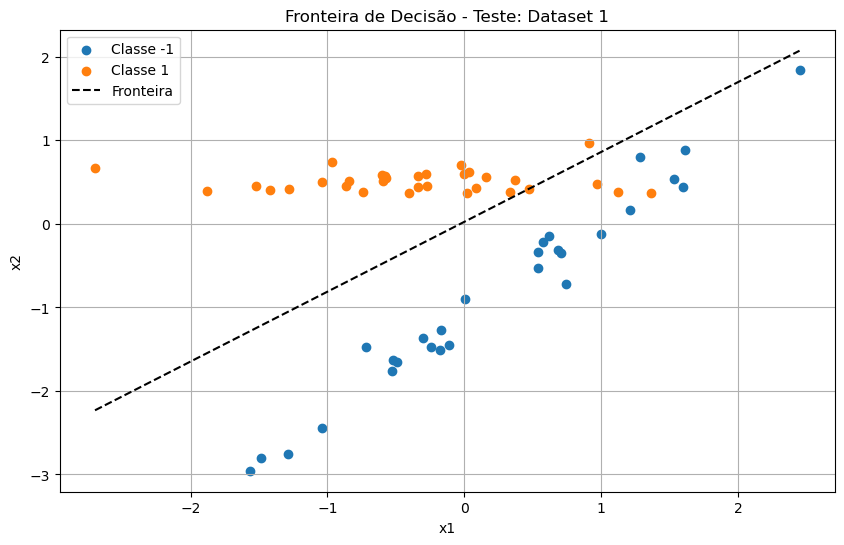

In [92]:
plot_decision_boundary(X_test1, y_test1, modelBGD, title='Fronteira de Decisão - Teste: Dataset 1')

#### Stochastic Gradient Descent

##### Treinamento

In [93]:
modelSGD = Adaline(learning_rate=0.01, epochs=100, precision=0.001, batch=False, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelSGD.fit(X_train1, y_train1)

print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelSGD.accuracy(X_train1, y_train1))

Pesos: [ 0.02015644 -0.75022647  0.84808684]
Épocas: 6
Acurácia: 0.9571428571428572


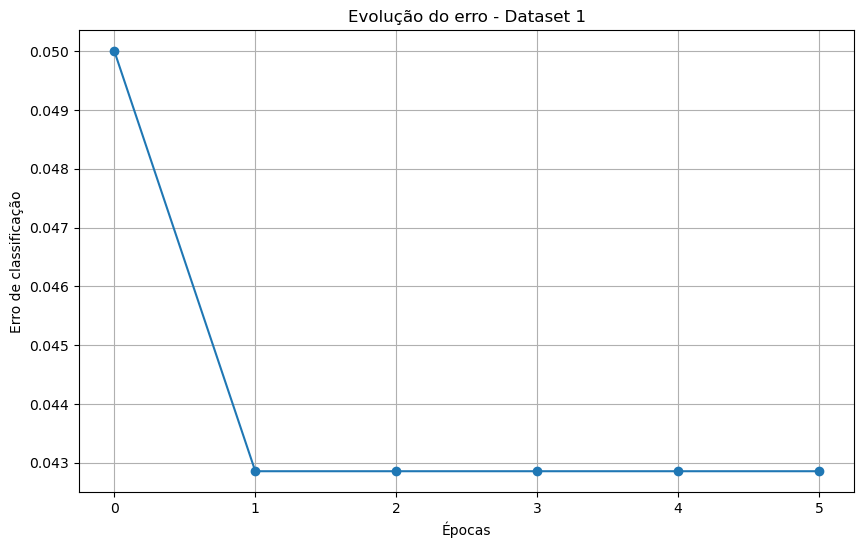

In [94]:
plot_error(modelSGD.errors_class, title="Evolução do erro - Dataset 1")

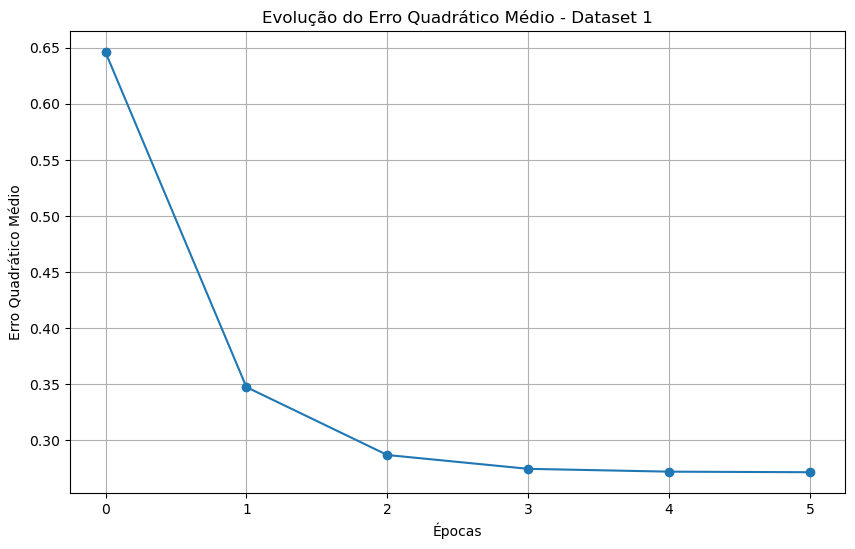

In [95]:
plot_error_qm(modelSGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 1")

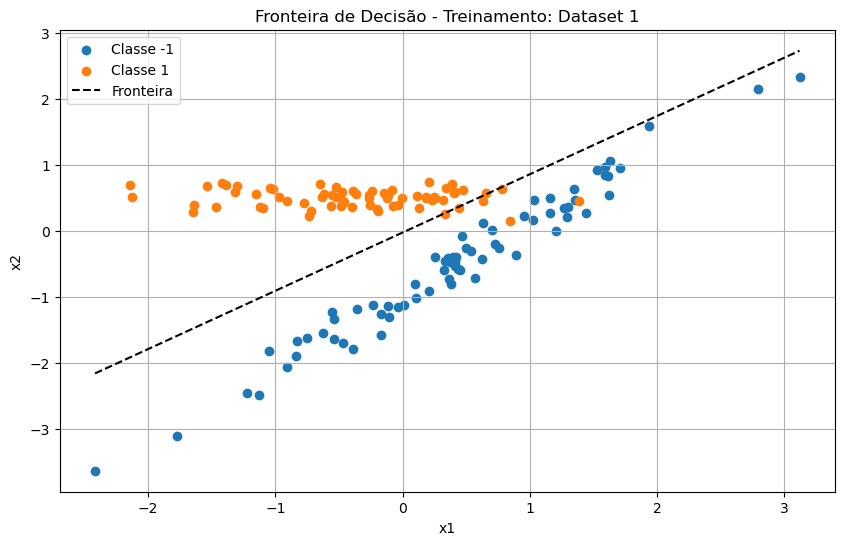

In [96]:
plot_decision_boundary(X_train1, y_train1, modelSGD, title='Fronteira de Decisão - Treinamento: Dataset 1')

##### Teste

In [97]:
print("Acurácia Treinamento:", modelSGD.accuracy(X_train1, y_train1))
print("Acurácia Teste:", modelSGD.accuracy(X_test1, y_test1))

Acurácia Treinamento: 0.9571428571428572
Acurácia Teste: 0.95


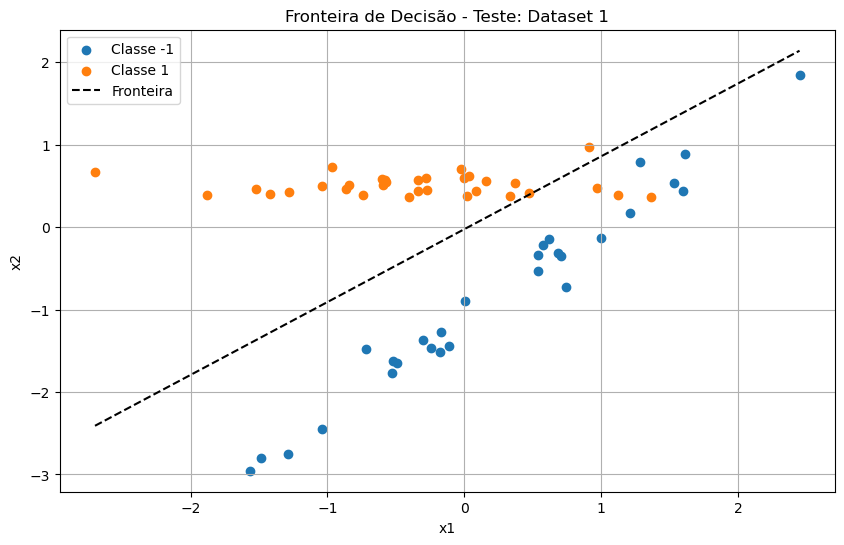

In [98]:
plot_decision_boundary(X_test1, y_test1, modelSGD, title='Fronteira de Decisão - Teste: Dataset 1')

#### Conclusões

---

### Dataset 2

* Realizar o treinamento e teste para taxa de aprendizado 0.01, precisão de 0.001 e com 100 épocas. Aqui foi utilizado uma seed 42 para gerar os pesos iniciais randomicamente.

In [99]:
df_train2 = pd.read_csv('train_dataset2.csv')
X_train2 = df_train2.drop('label', axis=1).values.T
y_train2 = df_train2['label'].values.reshape(1, -1)

In [100]:
df_test2 = pd.read_csv('test_dataset2.csv')
X_test2 = df_test2.drop('label', axis=1).values.T
y_test2 = df_test2['label'].values.reshape(1, -1)

#### Batch Gradient Descent

##### Treinamento

In [115]:
modelBGD = Adaline(learning_rate=0.01, epochs=100, precision=0.001, batch=True, seed=42)
weights, epochs_trained, errors_class, errors_ms = modelBGD.fit(X_train2, y_train2)


print("Pesos:", weights)
print("Épocas:", epochs_trained)
print("Acurácia:", modelBGD.accuracy(X_train2, y_train2))

Pesos: [ 0.00497881 -0.00173592  0.0060212 ]
Épocas: 2
Acurácia: 0.5771428571428572


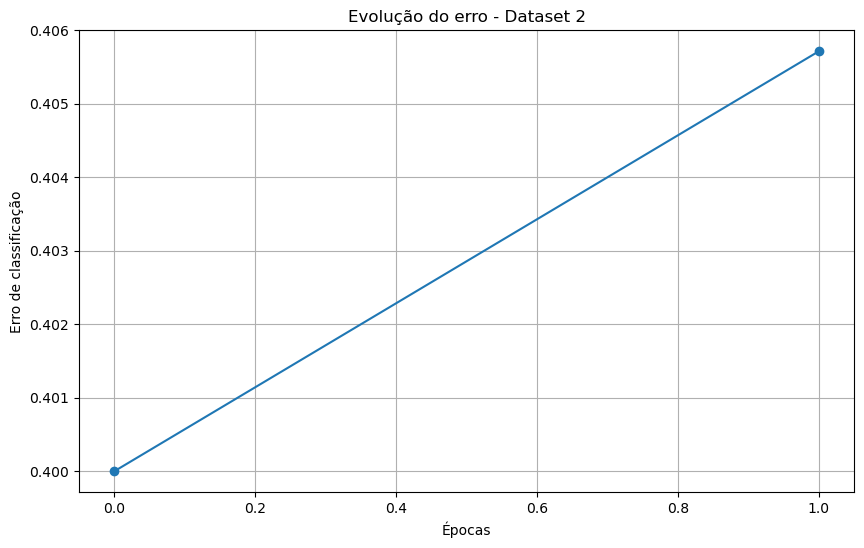

In [116]:
plot_error(modelBGD.errors_class, title="Evolução do erro - Dataset 2")

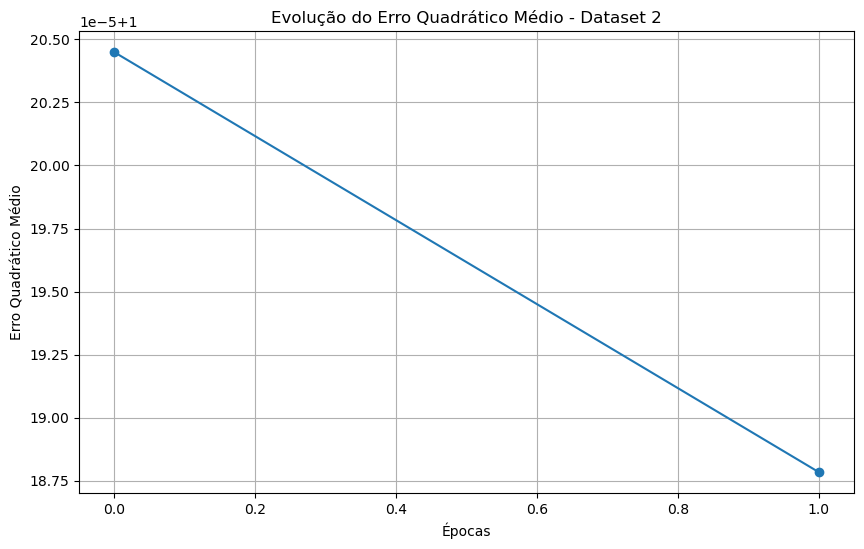

In [117]:
plot_error_qm(modelBGD.errors_ms, title="Evolução do Erro Quadrático Médio - Dataset 2")

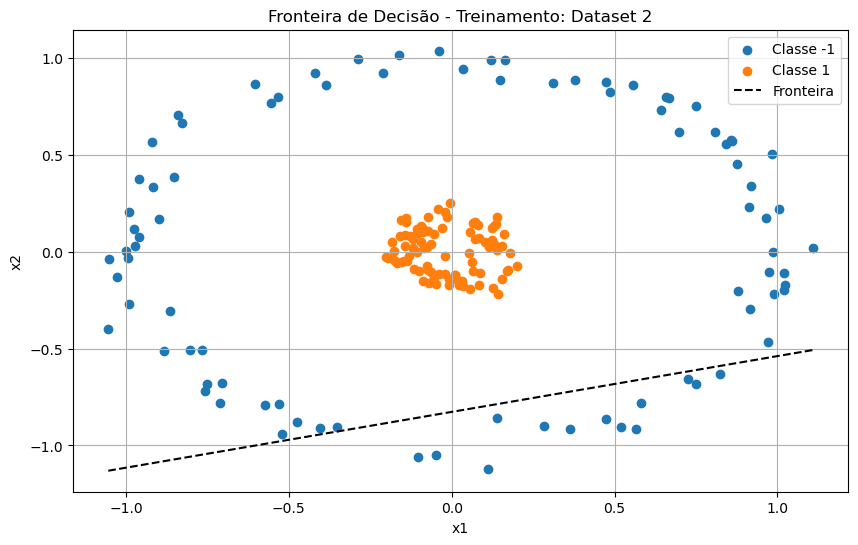

In [118]:
plot_decision_boundary(X_train2, y_train2, modelBGD, title='Fronteira de Decisão - Treinamento: Dataset 2')

##### Teste

In [119]:
print("Acurácia Treinamento:", modelBGD.accuracy(X_train2, y_train2))
print("Acurácia Teste:", modelBGD.accuracy(X_test2, y_test2))

Acurácia Treinamento: 0.5771428571428572
Acurácia Teste: 0.6666666666666666


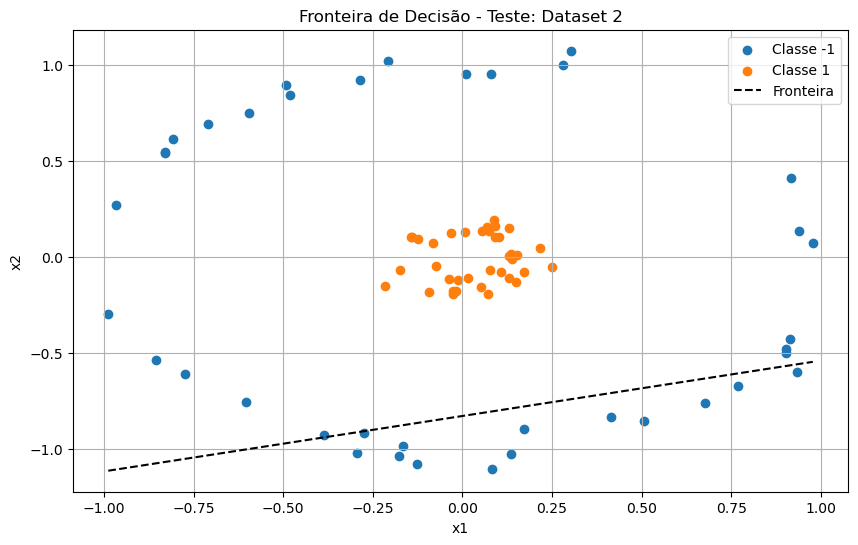

In [120]:
plot_decision_boundary(X_test2, y_test2, modelBGD, title='Fronteira de Decisão - Teste: Dataset 2')

#### Stochastic Gradient Descent

##### Treinamento

##### Teste

#### Conclusões

---

### Dataset 3